# Demo: Weighting with MAIC / entropy balancing

Every matcher elsewhere in `pybalance` (genetic, LP, propensity) works by **selecting a subset**
of the pool. `pybalance.weighting` instead **reweights every pool patient**, so nothing is
dropped -- some patients just count for more (or less) than others. This is the standard approach
for **Matching-Adjusted Indirect Comparison (MAIC)** (Signorovitch et al., 2010): reweighting a
trial's patient-level data ("IPD") so its weighted covariate moments match a comparator's
**published, aggregate-only** statistics (e.g. a Table 1 of means and proportions), enabling an
indirect treatment comparison when the comparator's own patient-level data isn't available.

- `MAICWeighter` -- the classic MAIC formulation: matches **means only** (i.e. category rates for
  categoric features), which is all a typical Table 1 discloses.
- `EntropyBalanceWeighter` -- the general form MAIC is a special case of: optionally *also*
  balances **variance** for any numeric feature whose target discloses (or, for a patient-level
  target, has) a standard deviation.

Both work with either an `AggregateTarget` (published summary statistics -- the typical MAIC
setting) or a patient-level target, and both return an ordinary `MatchingData`, just with every
pool row now carrying a fitted weight column.

In [2]:
import logging

import matplotlib.pyplot as plt
import pandas as pd

from pybalance.sim import generate_toy_dataset
from pybalance.utils import AggregateTarget, MatchingData, MatchingHeaders
from pybalance.visualization import plot_categoric_features, plot_numeric_features
from pybalance.weighting import (
    EntropyBalanceWeighter,
    MAICWeighter,
    weighted_balance_table,
)

%matplotlib inline

# show convergence / effective-sample-size diagnostics logged during fit()
logging.basicConfig(level=logging.INFO, format="%(message)s", force=True)

## 1. Synthetic data, and a "published Table 1"

As in the aggregate-matching demo, `generate_toy_dataset` gives us patient-level `pool` and
`target` populations -- entirely simulated. We keep the pool (our "IPD"), but for the target we
compute a handful of summary statistics as if reading them off a published Table 1, then discard
the patient-level target rows so nothing below can accidentally use them.

We start with a deliberately well-behaved feature set (`gender`, `haircolor`, `age`, `weight`,
`height`); Section 4 below revisits this choice.

In [3]:
m = generate_toy_dataset(n_pool=1000, n_target=100, seed=7)
pool = m.get_population("pool").drop(columns=[m.population_col])
target_patient_level = m.get_population("target").drop(columns=[m.population_col])

headers = MatchingHeaders(numeric=["age", "weight", "height"], categoric=["gender", "haircolor"])

numeric = {
    c: {"mean": float(target_patient_level[c].mean()), "std": float(target_patient_level[c].std())}
    for c in headers.numeric
}
categoric = {
    c: {k: float(v) for k, v in target_patient_level[c].value_counts(normalize=True).items()}
    for c in headers.categoric
}
aggregate_target = AggregateTarget(n=len(target_patient_level), numeric=numeric, categoric=categoric, headers=headers)

# From here on, only the disclosed AggregateTarget exists -- no patient-level target data.
del target_patient_level

matching_data = MatchingData(pool=pool, target=aggregate_target, headers=headers)
aggregate_target

feature,type,stat,value
age,numeric,mean,50.795973
age,numeric,std,15.019030
weight,numeric,mean,82.079040
weight,numeric,std,18.721164
height,numeric,mean,153.795053
height,numeric,std,15.715942
gender,categoric,0.0,0.550000
gender,categoric,1.0,0.450000
haircolor,categoric,2,0.400000
haircolor,categoric,1,0.350000


## 2. Fit `MAICWeighter`

`match()` fits (if needed) and returns a `MatchingData` with every pool patient retained, plus a
new `sample_weight` column (the default `weight_col`; note it's *not* called `"weight"`, since
`weight` here is itself a genuine covariate -- `MAICWeighter` refuses to silently clobber a
matching feature and raises if `weight_col` collides with one).

`weighted_balance_table()` compares each balanced feature's target moment to both the
**unweighted** and **weighted** pool moment -- the "weighted" column should land right on target.

In [4]:
weighter = MAICWeighter(matching_data, verbose=True)
matched = weighter.match()

weighted_balance_table(weighter)

MAICWeighter converged in 5 iterations. Effective sample size: 631.0 / 1000 pool patients.


,feature,moment,target,unweighted_pool,weighted_pool
0,gender_1.0,mean,0.450000,0.517000,0.450000
1,haircolor_1,mean,0.350000,0.298000,0.350000
2,haircolor_2,mean,0.400000,0.301000,0.400000
3,age,mean,50.795975,55.520107,50.795975
4,weight,mean,82.079041,88.016510,82.079041
5,height,mean,153.795059,160.308334,153.795059


In [5]:
print(f"Effective sample size: {weighter.effective_sample_size():.1f} / {len(pool)} pool patients")
print(f"Converged: {weighter.diagnostics['converged']}")
print(f"Weight summary (sums to target n={aggregate_target.n} by default):")
matched.get_population(matched.pool_name)["sample_weight"].describe()

Effective sample size: 631.0 / 1000 pool patients
Converged: True
Weight summary (sums to target n=100 by default):


count    1000.000000
mean        0.100000
std         0.076507
min         0.010935
25%         0.048423
50%         0.076510
75%         0.124405
max         0.609633
Name: sample_weight, dtype: float64

The **effective sample size (ESS)**, $\left(\sum_i w_i\right)^2 / \sum_i w_i^2$, summarizes how
"spread out" the weights are: it equals the pool size when all weights are equal, and shrinks
towards 1 as more and more of the total weight concentrates on fewer patients. A large drop from
the raw pool size is the standard MAIC red flag that the reweighting is relying heavily on a
small, possibly unrepresentative, slice of the pool -- worth showing alongside any MAIC result.

Since `sns.histplot` (which the plotting helpers below call) accepts a `weights=` column directly,
we can visualize the weighted vs. unweighted pool distributions with the same helpers used
elsewhere in `pybalance` -- just pass `weights="sample_weight"`.

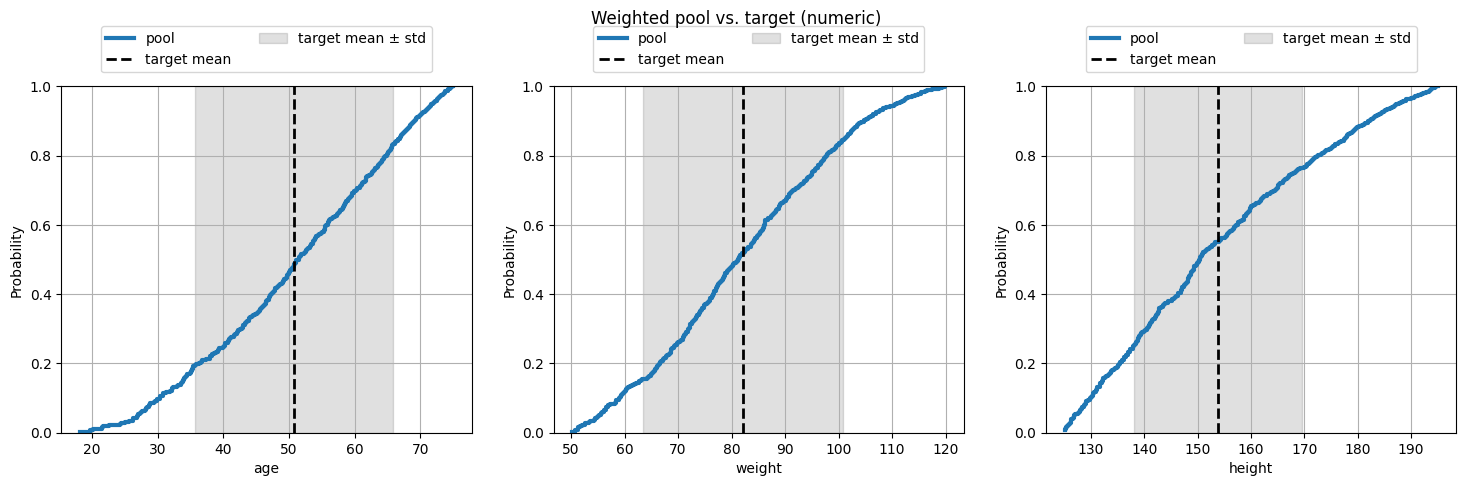

In [6]:
plot_numeric_features(matched, weights="sample_weight", include_only=headers.numeric, col_wrap=3)
plt.suptitle("Weighted pool vs. target (numeric)", y=1.05);

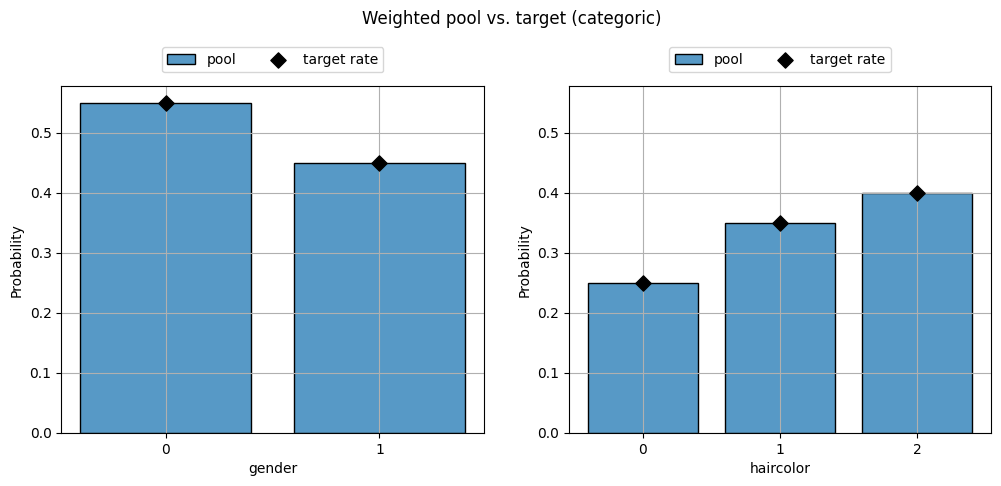

In [7]:
plot_categoric_features(matched, weights="sample_weight", include_only=headers.categoric, col_wrap=2)
plt.suptitle("Weighted pool vs. target (categoric)", y=1.05);

## 3. Generalizing: also balancing variance

A Table 1 sometimes discloses a standard deviation alongside a mean. `EntropyBalanceWeighter` is
the general form `MAICWeighter` is a (mean-only) special case of: pass `match_variance=True` to
*additionally* constrain the weighted variance of every numeric feature whose target discloses a
`std` (categoric features are never variance-constrained -- their variance is already fixed by
their matched rate).

In [11]:
variance_weighter = EntropyBalanceWeighter(matching_data, match_variance=True, verbose=True)
variance_weighter.match()

weighted_balance_table(variance_weighter)

EntropyBalanceWeighter converged in 6 iterations. Effective sample size: 493.6 / 1000 pool patients.


,feature,moment,target,unweighted_pool,weighted_pool
0,gender_1.0,mean,0.450000,0.517000,0.450000
1,haircolor_1,mean,0.350000,0.298000,0.350000
2,haircolor_2,mean,0.400000,0.301000,0.400000
3,age,mean,50.795975,55.520107,50.795975
4,age,variance,225.571251,171.687210,225.571241
5,weight,mean,82.079041,88.016510,82.079041
6,weight,variance,350.482008,273.742310,350.481995
7,height,mean,153.795059,160.308334,153.795059
8,height,variance,246.990845,379.825195,246.990845


## 4. When the target lies outside the pool's support

MAIC/entropy balancing needs the target to lie within the pool's covariate support -- there must
be *some* valid (possibly very uneven) weighting of the pool that reproduces the target's moments.
Unlike subset-selection matching (which always terminates, just possibly with poor balance),
reweighting can fail outright when this "positivity" assumption breaks down.

The toy pool is deliberately built with **zero** `country=0` patients, while the target has a
nonzero `country=0` rate (the same structural quirk the aggregate-matching demo's Use Case 3 calls
out). Since every pool patient's `country` is one of `{1, ..., 5}`, *any* reweighting of the pool
necessarily puts 100% of its mass on those five categories -- it's mathematically impossible to
also match the target's five corresponding rates, which sum to less than 100% (the rest being the
unreachable `country=0`). We use the actual patient-level target here (rather than the
`AggregateTarget` form used above) to make this concrete: an `AggregateTarget` that discloses a
rate for a category the pool doesn't contain at all silently drops that category from the
constraint set (it has no matching one-hot column to constrain), which would mask the very
infeasibility we want to demonstrate.


In [12]:
hard_headers = MatchingHeaders(numeric=["age", "weight", "height"], categoric=["gender", "country"])
hard_target_pl = m.get_population("target").drop(columns=[m.population_col])

print("country rate in pool:  ", pool["country"].value_counts(normalize=True).sort_index().to_dict())
print("country rate in target:", hard_target_pl["country"].value_counts(normalize=True).sort_index().to_dict())

hard_matching_data = MatchingData(pool=pool, target=hard_target_pl, headers=hard_headers)

hard_weighter = MAICWeighter(hard_matching_data, verbose=True)
hard_weighter.match()

weighted_balance_table(hard_weighter)

MAICWeighter did not converge within 200 iterations (max constraint violation = 0.4863). Weights may not exactly balance the requested moments; consider increasing max_iter/ridge, or check for unmatchable (e.g. near-extreme or non-overlapping) covariates.


country rate in pool:   {1: 0.108, 2: 0.224, 3: 0.274, 4: 0.284, 5: 0.11}
country rate in target: {0: 0.09, 1: 0.25, 2: 0.2, 3: 0.11, 4: 0.2, 5: 0.15}


,feature,moment,target,unweighted_pool,weighted_pool
0,gender_1.0,mean,0.450000,0.517000,0.693159
1,country_1,mean,0.250000,0.108000,0.294749
2,country_2,mean,0.200000,0.224000,0.319517
3,country_3,mean,0.110000,0.274000,0.034837
4,country_4,mean,0.200000,0.284000,0.336770
5,country_5,mean,0.150000,0.110000,0.014126
6,age,mean,50.795975,55.520107,43.507245
7,weight,mean,82.079033,88.016510,77.781079
8,height,mean,153.795044,160.308334,148.028941


As expected, the fit reports `converged: False`. Because a valid reweighting of the pool can only
ever distribute 100% of its mass across `country in {1, ..., 5}`, it's mathematically impossible
to simultaneously hit the target's rates for those five categories, which sum to only 91% (the
rest being the unreachable `country=0`) -- there's no weighting that can reconcile the two.
Notice how the optimizer, unable to satisfy the `country` constraints, ends up trading away
balance on *every other* feature too (`gender`, `age`, `weight`, `height` are all now visibly off
target) while it searches for a best-effort compromise, and the effective sample size drops
sharply. This is exactly the honest, "don't silently produce a wrong answer" behavior we want. If
you hit this in practice: check for categories/ranges the target has that the pool structurally
lacks, consider dropping the offending feature, or fall back to subset-selection matching (which
can't invent missing categories either, but degrades more gracefully -- see the aggregate-matching
demo).


In [10]:
print(f"Converged: {hard_weighter.diagnostics['converged']}")
print(f"Max constraint violation: {hard_weighter.diagnostics['max_constraint_violation']:.3f}")
print(f"Effective sample size: {hard_weighter.effective_sample_size():.1f} / {len(pool)} pool patients")

Converged: False
Max constraint violation: 0.486
Effective sample size: 222.6 / 1000 pool patients


## Takeaways

- Weighting keeps **every** pool patient, unlike the subset-selection matchers elsewhere in
  `pybalance` -- some patients just count for more or less. `MAICWeighter` is the classic
  mean-only MAIC formulation; `EntropyBalanceWeighter(match_variance=True)` generalizes it to also
  balance disclosed variances.
- Both work directly against an `AggregateTarget` (the typical MAIC use case -- a published Table
  1) or a patient-level target.
- Always check `effective_sample_size()` and `.diagnostics["converged"]` alongside any fitted
  weights -- a low ESS or non-convergence is the signal that the reweighting is stretching thin (or
  failing outright) to reach the target, most often because of a genuine covariate-support mismatch
  between pool and target.